# This is a sample Jupyter Notebook

Below is an implementation of the project.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

In [12]:
# load
train_path = ("data/mitbih_train.csv")
test_path = ("data/mitbih_test.csv")

train = pd.read_csv(train_path)
train = train.rename(columns={train.columns[-1]: "label"})
test = pd.read_csv(test_path)
test = test.rename(columns={test.columns[-1]: "label"})

# distribution
x_train = train.drop("label", axis=1)
y_train = train["label"]

x_test = test.drop("label", axis=1)
y_test = test["label"]

print(train.head())

   9.779411554336547852e-01  9.264705777168273926e-01  \
0                  0.960114                  0.863248   
1                  1.000000                  0.659459   
2                  0.925414                  0.665746   
3                  0.967136                  1.000000   
4                  0.927461                  1.000000   

   6.813725233078002930e-01  2.450980395078659058e-01  \
0                  0.461538                  0.196581   
1                  0.186486                  0.070270   
2                  0.541436                  0.276243   
3                  0.830986                  0.586854   
4                  0.626943                  0.193437   

   1.544117629528045654e-01  1.911764740943908691e-01  \
0                  0.094017                  0.125356   
1                  0.070270                  0.059459   
2                  0.196133                  0.077348   
3                  0.356808                  0.248826   
4                  0.094991  

In [13]:
x_train.info()

procent_null = 100 * x_train.isnull().sum().sum() / x_train.size
print(f"Procent brakujacych danych: {procent_null:.2f}%")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87553 entries, 0 to 87552
Columns: 187 entries, 9.779411554336547852e-01 to 0.000000000000000000e+00.87
dtypes: float64(187)
memory usage: 124.9 MB
Procent brakujacych danych: 0.00%


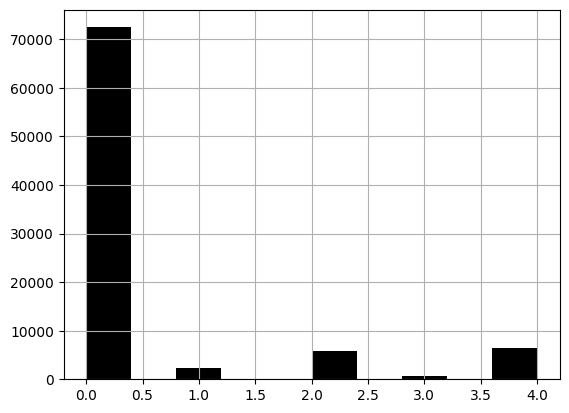

In [41]:
y_train.hist(bins = 10, color='black')
plt.show()

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

proc_pipeline = Pipeline(steps=[
    ('std_scaler', StandardScaler()),
])

column_transformer = ColumnTransformer([
    ('num', proc_pipeline, x_train.columns),
])

preprocessor = Pipeline(steps=[
    ('column_transformer', column_transformer),
])

x_ready = preprocessor.fit_transform(x_train)
print(x_ready.head())

[[ 0.2895502   0.47377598  0.165282   ... -0.09259671 -0.08959417
  -0.08794015]
 [ 0.45511508 -0.44496568 -1.04478288 ... -0.09259671 -0.08959417
  -0.08794015]
 [ 0.14551419 -0.41662471  0.51678573 ... -0.09259671 -0.08959417
  -0.08794015]
 ...
 [ 0.06543439 -0.60261994  0.75647348 ... -0.09259671 -0.08959417
  -0.08794015]
 [-0.13337351 -0.50758545  1.85479028 ... -0.09259671 -0.08959417
  -0.08794015]
 [ 0.04627329  0.39550536  1.65736978 ... -0.09259671 -0.08959417
  -0.08794015]]


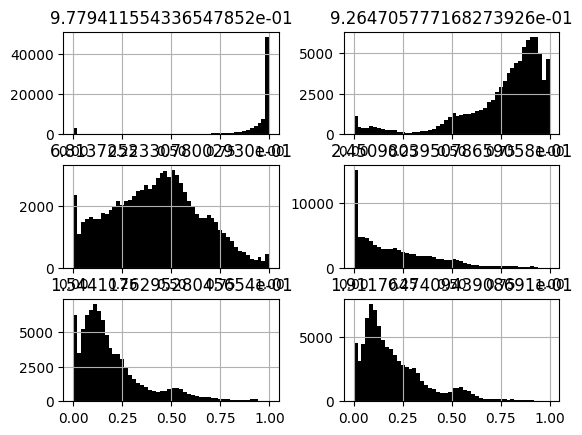

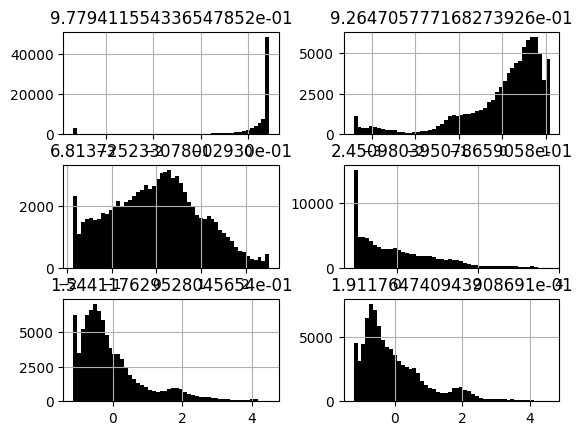

In [42]:
col = x_train.columns[:6]

x_train[col].hist(bins = 50, color='black')
plt.show()

x_ready_df = pd.DataFrame(x_ready, columns=x_train.columns)
x_ready_df[col].hist(bins = 50, color='black')
plt.show()

In [40]:
print("Before:")
print(x_train.iloc[:, :3].mean(), x_train.iloc[:, :3].std())

print("After:")
print(x_ready_df.iloc[:, :3].mean(), x_ready_df.iloc[:, :3].std())

Before:
9.779411554336547852e-01    0.890359
9.264705777168273926e-01    0.758158
6.813725233078002930e-01    0.423969
dtype: float64 9.779411554336547852e-01    0.240910
9.264705777168273926e-01    0.221814
6.813725233078002930e-01    0.227305
dtype: float64
After:
9.779411554336547852e-01    5.193967e-17
9.264705777168273926e-01    8.310346e-17
6.813725233078002930e-01    2.596983e-17
dtype: float64 9.779411554336547852e-01    1.000006
9.264705777168273926e-01    1.000006
6.813725233078002930e-01    1.000006
dtype: float64
